In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df5 = pd.read_csv('E:\Gen AI\AQI_Analysis\Dataset\city_hour.csv')

In [3]:
df5.sample(5)

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
466420,Kolkata,2019-06-11 15:00:00,31.87,58.09,13.88,13.32,25.15,4.72,0.28,1.79,44.58,5.06,6.58,4.41,72.0,Satisfactory
684912,Visakhapatnam,2017-11-17 06:00:00,7.75,11.25,2.30,14.80,9.75,0.77,0.63,5.88,14.90,1.00,1.28,0.20,79.0,Satisfactory
403757,Jaipur,2018-02-26 14:00:00,27.16,105.07,12.24,30.74,32.68,23.12,0.35,6.68,80.06,0.27,0.24,NaN,98.0,Satisfactory
264462,Delhi,2017-03-14 19:00:00,75.55,269.44,22.38,49.99,20.80,23.48,0.44,23.53,31.39,2.56,7.02,NaN,334.0,Very Poor
448881,Jorapokhar,2020-02-09 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df5['City'].value_counts()

City
Ahmedabad             48192
Delhi                 48192
Mumbai                48192
Bengaluru             48192
Lucknow               48192
Chennai               48192
Hyderabad             48107
Patna                 44554
Gurugram              40258
Visakhapatnam         35053
Amritsar              29269
Jorapokhar            28025
Jaipur                26705
Thiruvananthapuram    26651
Amaravati             22784
Brajrajnagar          22468
Talcher               22161
Kolkata               19503
Guwahati              12002
Coimbatore             9229
Shillong               7402
Chandigarh             7263
Bhopal                 6903
Kochi                  3854
Ernakulam              3852
Aizawl                 2680
Name: count, dtype: int64

In [5]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 707875 entries, 0 to 707874
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   City        707875 non-null  object 
 1   Datetime    707875 non-null  object 
 2   PM2.5       562787 non-null  float64
 3   PM10        411138 non-null  float64
 4   NO          591243 non-null  float64
 5   NO2         590753 non-null  float64
 6   NOx         584651 non-null  float64
 7   NH3         435333 non-null  float64
 8   CO          621358 non-null  float64
 9   SO2         577502 non-null  float64
 10  O3          578667 non-null  float64
 11  Benzene     544229 non-null  float64
 12  Toluene     487268 non-null  float64
 13  Xylene      252046 non-null  float64
 14  AQI         578795 non-null  float64
 15  AQI_Bucket  578795 non-null  object 
dtypes: float64(13), object(3)
memory usage: 86.4+ MB


In [6]:
df5.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,562787.000000,411138.000000,591243.000000,590753.000000,584651.000000,435333.000000,621358.000000,577502.000000,578667.000000,544229.000000,487268.000000,252046.000000,578795.000000
mean,67.622994,119.075804,17.421755,28.885157,32.287565,23.607959,2.183539,14.038307,34.798979,3.087595,8.660927,3.130537,166.413500
std,74.730496,104.224752,32.095211,29.162194,39.756669,28.831900,10.970514,19.305540,29.806379,16.456599,21.741023,7.834832,162.112729
min,0.010000,0.010000,0.010000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,8.000000
25%,26.200000,52.380000,3.840000,10.810000,10.660000,8.120000,0.420000,4.880000,13.420000,0.050000,0.370000,0.100000,79.000000
50%,46.420000,91.500000,7.960000,20.320000,20.790000,15.380000,0.800000,8.370000,26.240000,0.860000,2.590000,0.790000,116.000000
75%,79.490000,147.520000,16.150000,36.350000,37.150000,29.230000,1.370000,14.780000,47.620000,2.750000,8.410000,3.120000,208.000000
max,999.990000,1000.000000,499.990000,499.510000,498.610000,499.970000,498.570000,199.960000,497.620000,498.070000,499.400000,499.990000,3133.000000


In [7]:
df5.isnull().mean()*100

City           0.000000
Datetime       0.000000
PM2.5         20.496274
PM10          41.919407
NO            16.476355
NO2           16.545577
NOx           17.407593
NH3           38.501430
CO            12.222073
SO2           18.417517
O3            18.252940
Benzene       23.117923
Toluene       31.164683
Xylene        64.393996
AQI           18.234858
AQI_Bucket    18.234858
dtype: float64

### Observation
The data has missing values, so some later results may not use every row. It is good to keep that in mind before comparing cities or hours.



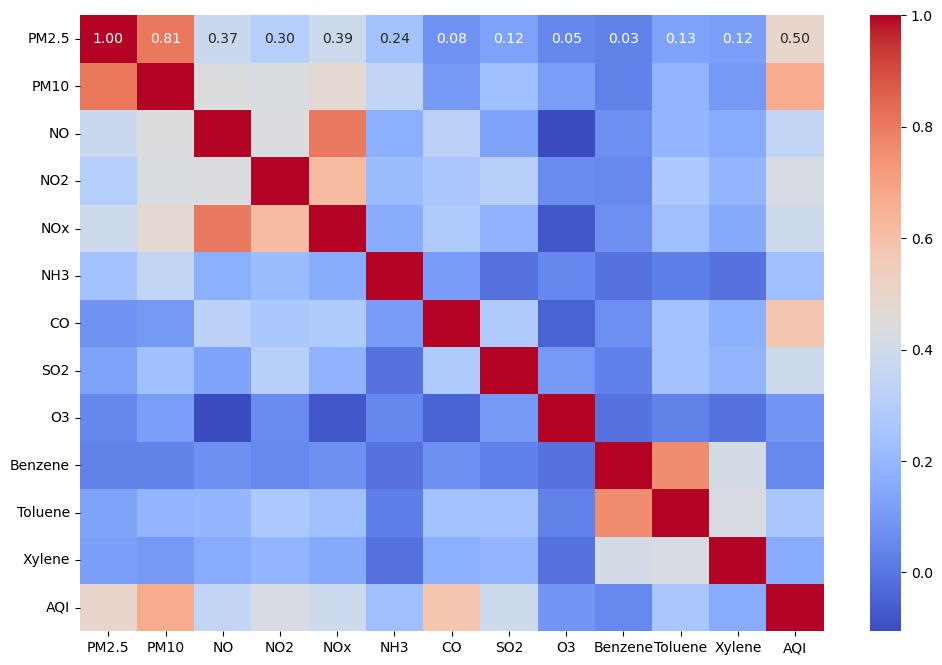

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df5.select_dtypes(include='number').corr(), 
            annot=True, 
            cmap='coolwarm',
            fmt='.2f')
plt.show()

### Observation
The heatmap shows which pollution values move together. Stronger values mean two things often go up and down together.



(0.0, 300.0)

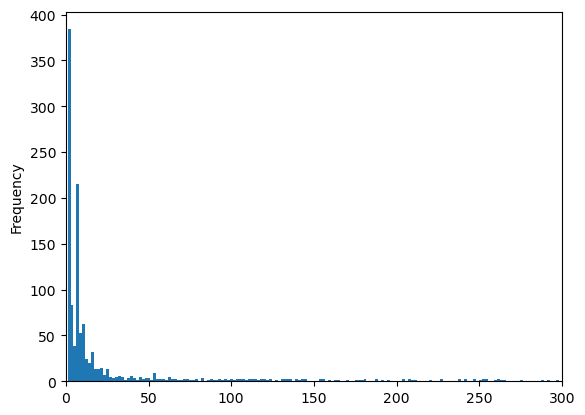

In [9]:
df5['AQI'].value_counts().plot(kind='hist',bins=3000)
plt.xlim(0,300)

### Observation
Most AQI values stay in the lower range on this plot, but there are some much higher values too. So the data is not evenly spread.



In [10]:
df5['Datetime'] = pd.to_datetime(df5['Datetime'])


In [11]:
df5['Time']=df5['Datetime'].dt.time


In [12]:
cities = ['Ahmedabad', 'Delhi', 'Patna', 'Gurugram', 'Lucknow']

In [13]:
df5['Hour'] = df5['Datetime'].dt.hour

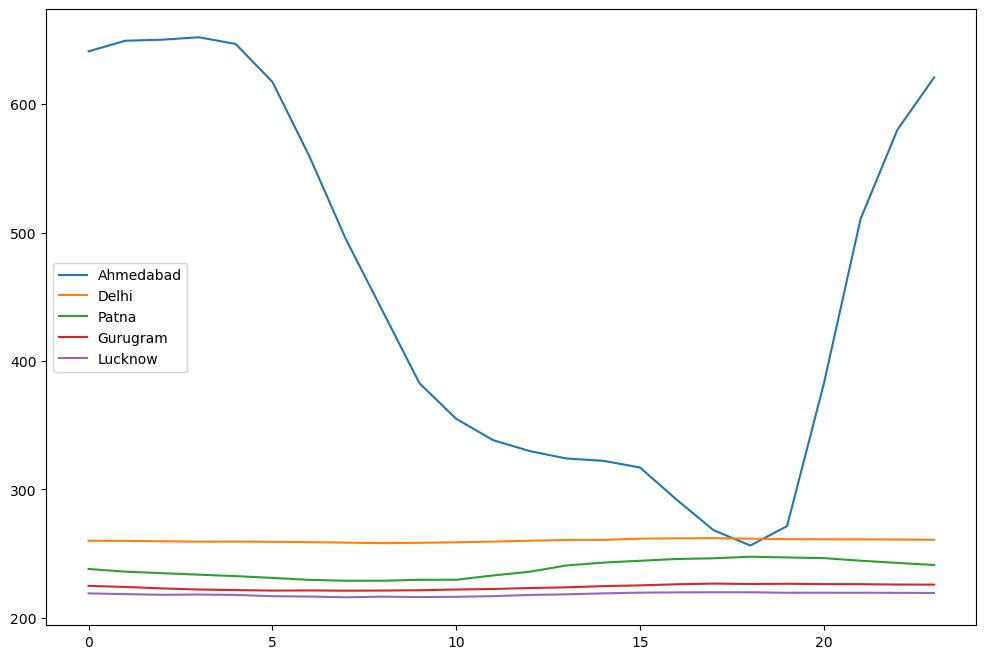

In [14]:
plt.figure(figsize=(12, 8))
for city in cities:
    city_data = df5[df5['City'] == city]
    hourly = city_data.groupby('Hour')['AQI'].mean()
    plt.plot(hourly.index, hourly.values, label=city)

plt.legend()
plt.show()

### Observation
This plot shows AQI changes by hour in all selected cities. The line shape suggests air quality gets worse late at night and early morning, then improves in the afternoon.



In [15]:
cities2 = [ 'Delhi', 'Patna', 'Gurugram', 'Lucknow']


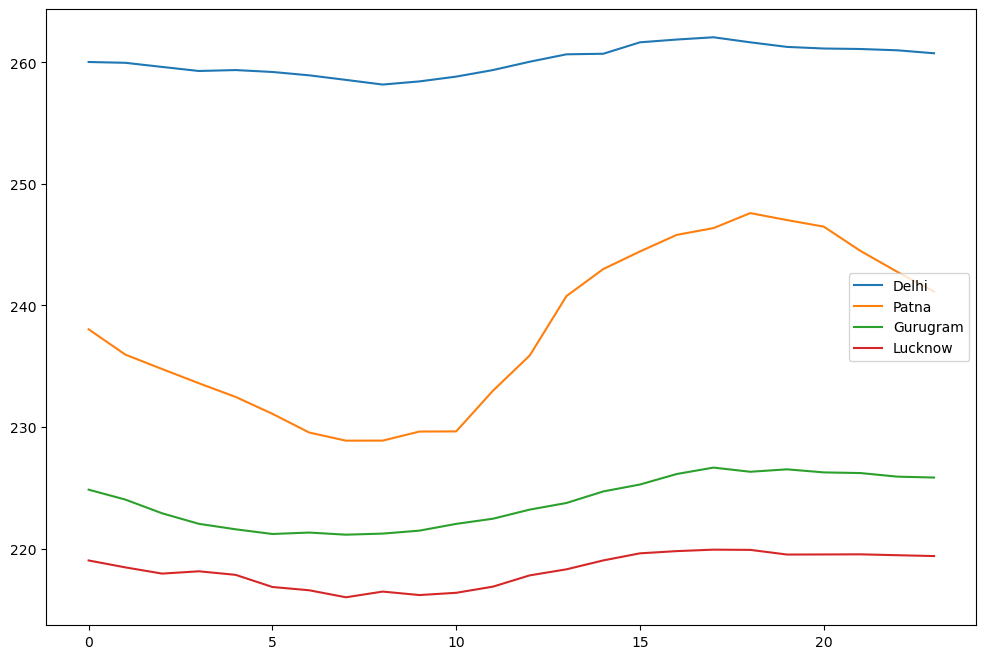

In [16]:
plt.figure(figsize=(12, 8))
for city in cities2:
    city_data = df5[df5['City'] == city]
    hourly = city_data.groupby('Hour')['AQI'].mean()
    plt.plot(hourly.index, hourly.values, label=city)

plt.legend()
plt.show()

### Observation
Even after removing Ahmedabad, the same hourly pattern is still visible. That means the day-night AQI change is not caused by just one city.



### Hypothesis Testing
We can test whether AQI really changes by hour, or if the hourly pattern is just random.



In [17]:
from scipy.stats import kruskal

hour_groups = [group['AQI'].dropna() for _, group in df5.groupby('Hour') if group['AQI'].dropna().shape[0] > 0]
stat, p_value = kruskal(*hour_groups)
print('Kruskal-Wallis statistic:', stat)
print('p-value:', p_value)

if p_value < 0.05:
    print('Conclusion: AQI changes by hour in a meaningful way.')
else:
    print('Conclusion: The hourly difference may be due to random variation.')

Kruskal-Wallis statistic: 781.1025250300755
p-value: 3.42483641713144e-150
Conclusion: AQI changes by hour in a meaningful way.


### Observation
If the p-value is below 0.05, we can say the hourly AQI pattern is real in this data. Kruskal-Wallis fits better here because AQI is usually not perfectly normal.



## Final Conclusion
AQI changes through the day in a clear pattern in this notebook.

Late night and early morning hours usually show higher AQI, while afternoon hours look cleaner.

Ahmedabad stands out with much higher AQI than the other cities in the first hourly plot.

The second hourly plot shows the same pattern even without Ahmedabad, so the pattern is shared across cities.

The hypothesis test is added for hourly AQI because that is the main point of this notebook.

